# 판다스를 이용한 기상 데이터 분석

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [114]:
weather = pd.read_csv('./csv/weather.csv', encoding='CP949')
print(weather.head(3))
print('weather 데이터의 shape : ', weather.shape)

           일시  평균기온  최대풍속  평균풍속
0  2010-08-01  28.7   8.3   3.4
1  2010-08-02  25.2   8.7   3.8
2  2010-08-03  22.1   6.3   2.9
weather 데이터의 shape :  (3653, 4)


In [115]:
print(weather.shape)
print(weather.describe())

(3653, 4)
              평균기온         최대풍속         평균풍속
count  3653.000000  3649.000000  3647.000000
mean     12.942102     7.911099     3.936441
std       8.538507     3.029862     1.888473
min      -9.000000     2.000000     0.200000
25%       5.400000     5.700000     2.500000
50%      13.800000     7.600000     3.600000
75%      20.100000     9.700000     5.000000
max      31.300000    26.000000    14.900000


In [116]:
len(weather.isna().any()) # 숫자가 아닌 행이 하나라도 있는가? (NaN)

4

In [113]:
print(weather.mean())

TypeError: Cannot perform reduction 'mean' with string dtype

In [117]:
print(weather["평균기온"].mean)
print(weather.std())

<bound method Series.mean of 0       28.7
1       25.2
2       22.1
3       25.3
4       27.2
        ... 
3648    22.1
3649    21.9
3650    21.6
3651    22.9
3652    25.7
Name: 평균기온, Length: 3653, dtype: float64>


TypeError: Cannot perform reduction 'std' with string dtype

## 데이터 정제와 결손값의 처리

In [ ]:
weather[weather.isna()]

,평균기온,최대풍속,평균풍속
일시,,,
2010-08-01,NaN,NaN,NaN
2010-08-02,NaN,NaN,NaN
2010-08-03,NaN,NaN,NaN
2010-08-04,NaN,NaN,NaN
2010-08-05,NaN,NaN,NaN
...,...,...,...
2020-07-27,NaN,NaN,NaN
2020-07-28,NaN,NaN,NaN
2020-07-29,NaN,NaN,NaN


In [ ]:
평균풍속갯수 = weather['평균풍속'].isna().sum()
print(평균풍속갯수)

6


In [ ]:
all_na = weather.isna().sum()
print(all_na)

all_na = weather.isna().sum().sum()
print(all_na)

평균기온    0
최대풍속    4
평균풍속    6
dtype: int64
10


In [ ]:
new_weather = weather.dropna(how='any', axis=0, inplace=False) # 결손데이터가 하나라도 걸려있으면 행 자체를 삭제해라

In [ ]:
print(new_weather[new_weather.isnull().any(axis=1)]) #NULL값 있는 컬럼을 출력해라

Empty DataFrame
Columns: [평균기온, 최대풍속, 평균풍속]
Index: []


In [ ]:
print(new_weather.describe())

              평균기온         최대풍속         평균풍속
count  3646.000000  3646.000000  3646.000000
mean     12.954717     7.907899     3.936890
std       8.538707     3.029047     1.888538
min      -9.000000     2.000000     0.200000
25%       5.400000     5.700000     2.500000
50%      13.800000     7.600000     3.600000
75%      20.100000     9.700000     5.000000
max      31.300000    26.000000    14.900000


In [ ]:
new_weather_mean_windy = weather['평균풍속'].fillna(3.9, inplace = False)
print(new_weather_mean_windy)
weather.loc['2012-02-11']

일시
2010-08-01    3.4
2010-08-02    3.8
2010-08-03    2.9
2010-08-04    4.2
2010-08-05    5.6
             ... 
2020-07-27    1.7
2020-07-28    1.6
2020-07-29    1.0
2020-07-30    2.4
2020-07-31    2.5
Name: 평균풍속, Length: 3653, dtype: float64


평균기온   -0.7
최대풍속    NaN
평균풍속    NaN
Name: 2012-02-11, dtype: float64

In [ ]:
new_weather_mean_windy.loc['2012-02-11']

np.float64(3.9)

In [ ]:
d_list = ["2018-01-11",  "2018/01/11", "01/11/2018", "01/11/2018"]
print(pd.DatetimeIndex(d_list))
new_d_index = pd.DatetimeIndex(d_list)
new_d_index.year

DatetimeIndex(['2018-01-11', '2018-01-11', '2018-01-11', '2018-01-11'], dtype='datetime64[us]', freq=None)


Index([2018, 2018, 2018, 2018], dtype='int32')

In [ ]:
d_list = ["01, 03, 2018 11:12:13", "01-03-2018 11:22:13"]
pd.DatetimeIndex(d_list).hour

Index([11, 11], dtype='int32')

In [118]:
weather['month2'] = pd.DatetimeIndex(weather['일시']).month
weather

,일시,평균기온,최대풍속,평균풍속,month2
0,2010-08-01,28.7,8.3,3.4,8
1,2010-08-02,25.2,8.7,3.8,8
2,2010-08-03,22.1,6.3,2.9,8
3,2010-08-04,25.3,6.6,4.2,8
4,2010-08-05,27.2,9.1,5.6,8
...,...,...,...,...,...
3648,2020-07-27,22.1,4.2,1.7,7
3649,2020-07-28,21.9,4.5,1.6,7
3650,2020-07-29,21.6,3.2,1.0,7
3651,2020-07-30,22.9,9.7,2.4,7


In [ ]:
weather.loc[:]

,일시,평균기온,최대풍속,평균풍속
0,1970,28.7,8.3,3.4
1,1970,25.2,8.7,3.8
2,1970,22.1,6.3,2.9
3,1970,25.3,6.6,4.2
4,1970,27.2,9.1,5.6
...,...,...,...,...
3648,1970,22.1,4.2,1.7
3649,1970,21.9,4.5,1.6
3650,1970,21.6,3.2,1.0
3651,1970,22.9,9.7,2.4


In [ ]:
monthly_wind = [None for _ in range(12)] #리스트 컴프리헨션
print(monthly_wind)

[None, None, None, None, None, None, None, None, None, None, None, None]


              일시  평균기온  최대풍속  평균풍속  month2
153   2011-01-01   0.8  19.0  11.1       1
154   2011-01-02   0.1   8.5   6.0       1
155   2011-01-03  -0.3  10.2   6.5       1
156   2011-01-04   1.7   6.8   3.1       1
157   2011-01-05   1.2   6.9   4.1       1
...          ...   ...   ...   ...     ...
3466  2020-01-27   5.4  15.3   7.6       1
3467  2020-01-28   5.7  14.9  11.6       1
3468  2020-01-29   4.1   9.0   6.6       1
3469  2020-01-30   1.8  10.2   7.7       1
3470  2020-01-31   1.9  10.2   5.3       1

[310 rows x 5 columns]
              일시  평균기온  최대풍속  평균풍속  month2
184   2011-02-01   3.1   4.9   2.0       2
185   2011-02-02   4.5   5.3   2.5       2
186   2011-02-03   5.4   4.5   2.4       2
187   2011-02-04   5.3   9.1   3.5       2
188   2011-02-05   3.8   6.5   2.4       2
...          ...   ...   ...   ...     ...
3495  2020-02-25   6.6  12.2   6.5       2
3496  2020-02-26   3.6  10.8   7.2       2
3497  2020-02-27   2.0  11.2   5.9       2
3498  2020-02-28   4.1   6.6  

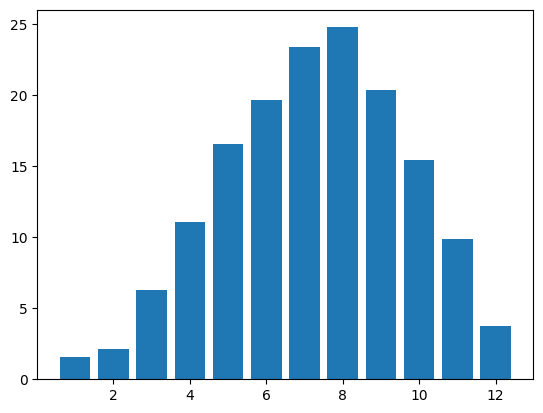

In [119]:
for i in range(12) :
    print(weather[weather['month2'] == i + 1])
    monthly_wind[i] = (weather[weather['month2'] == i + 1])['평균기온'].mean()
    #print(len(monthly_wind))
print(monthly_wind)
plt.bar([i for i in range(1,13)], monthly_wind)
plt.show()